In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st

# Bayesian analysis in Python

Bayesian analysis is one of the main frameworks for conducting statistical inference.  It differs from the *frequentist* framework used elsewhere in this course.  The Bayesian and frequentist approaches to estimation and inference are both rigorous and applicable to a wide array of settings.  In many situations they will give similar conclusions.  The precise mathematical definitions used to accomplish goals such as uncertainty assessment differ between the Bayesian and frequentist settings, and the algorithms used to calculate Bayesian estimates are quite different from those used to calculate frequentist estimates.

In this notebook we illustrate some key concepts from Bayesian analysis.  This notebook will not teach you how to analyze data using Bayesian methods.  There are well-maintained packages including [pystan](https://pystan.readthedocs.io/en/latest) that serve this purpose well.  

## Notation and terminology

We focus on the setting of parameter estimation and uncertainty assessment.  As is typical in most statistical analysis, we have a model that depends on unknown parameters, here denoted $\theta$.  The goal is the use data to estimate $\theta$ and then to assess the precision of this estimate.

$\theta$: a parameter that governs the system being observed, the goal is to learn about $\theta$

$D$: the data that we observe

__Likelihood__ $p(D|\theta)$: the probability of observing the data $D$, for a given value of the parameter $\theta$, calculated using a chosen family of *probability models*

__Prior distribution__ $p(\theta)$: what we know about the value of $\theta$ before seeing data

__Posterior distribution__ $p(\theta|D)$: a result of Bayesian analysis that reflects all that we know about $\theta$ from our data and model

__Evidence__ $p(D)$: the probability of observing the data averaged over all the possible values of the parameter $\theta$

## Bayes' theorem

Most Bayesian analysis is predicated on *Bayes' theorem*, which states that $p(\theta|D) = P(D|\theta)P(\theta)/P(D)$.  That is, the posterior distribution is the likelihood time the prior divided by the evidence.

The evidence $p(D)$ can be considered to be a normalizing constant.  In practice we usually work with the *un-normalized posterior* $p(\theta|D) \propto p(D|\theta) \cdot p(\theta)$.

# Pythonによるベイズ分析

ベイズ分析は、統計的推測を行うための主要な枠組みの1つです。本講義で主に扱う*頻度主義*（frequentist）の枠組みとは異なります。ベイズ的アプローチと頻度主義的アプローチは、いずれも厳密であり、幅広い設定に適用できます。多くの状況では、両者は似た結論を与えます。ただし、不確実性の評価などの目的を達成するための数学的定義は両者で異なり、ベイズ推定の計算アルゴリズムも頻度主義のものとは大きく異なります。

このノートブックでは、ベイズ分析の重要な概念をいくつか示します。ここではベイズ手法による実データ分析の方法そのものを網羅的に学ぶわけではありません。実際の分析には、[pystan](https://pystan.readthedocs.io/en/latest) のようなよく整備されたパッケージが有用です。

## 記法と用語

ここでは、パラメータ推定と不確実性評価の設定に焦点を当てます。多くの統計解析と同様に、未知パラメータ（ここでは $\theta$）に依存するモデルを考えます。目的は、データを用いて $\theta$ を推定し、その推定精度を評価することです。

$\theta$: 観測対象の系を支配するパラメータ。$\theta$ について学ぶことが目的

$D$: 観測されるデータ

__尤度__ $p(D|\theta)$: 与えたパラメータ値 $\theta$ のもとでデータ $D$ が観測される確率。選択した*確率モデル*の族に基づいて計算される

__事前分布__ $p(\theta)$: データを見る前に $\theta$ について持っている知識

__事後分布__ $p(\theta|D)$: データとモデルから得られる、$\theta$ に関する知識を反映したベイズ分析の結果

__エビデンス__ $p(D)$: パラメータ $\theta$ のあらゆる可能な値について平均化した、データが観測される確率

## ベイズの定理

ベイズ分析の多くは*ベイズの定理*に基づきます。定理は $p(\theta|D) = P(D|\theta)P(\theta)/P(D)$ を与えます。つまり、事後分布は尤度と事前分布の積をエビデンスで割ったものです。

エビデンス $p(D)$ は正規化定数とみなせます。実務では通常、*非正規化事後分布* $p(\theta|D) \propto p(D|\theta) \cdot p(\theta)$ を扱います。

## Coin - Flipping Problem

We will illustrate these ideas in the context of a coin-flipping experiment.

For a fair coin, the sample space is {_heads_, _tails_}, and each of these outcomes has probability 1/2. 

Now suppose that we have a coin and don't know whether it is fair.  The actual probability of this coin landing heads-up is the parameter $\theta$.

The exact value of $\theta$ can never be known, but we are able to conduct an experiment where we flip this coin $n$ times and observe $x$ heads and $n-x$ tails.  In the notation introduced above, the data $D$ is $(x, n)$.  

The likelihood $p(D|\theta)$ is a single number that captures how well the data match the parameter value $\theta$.

## コイン投げ問題

これらの考え方を、コイン投げ実験を例にして説明します。

公平なコインでは、標本空間は {_表_, _裏_} であり、各結果の確率は 1/2 です。

ここで、手元のコインが公平かどうかわからないとします。このコインが表になる確率をパラメータ $\theta$ とします。

$\theta$ の正確な値を完全に知ることはできませんが、コインを $n$ 回投げて表が $x$ 回、裏が $n-x$ 回だったという実験は行えます。先の記法では、データ $D$ は $(x, n)$ です。

尤度 $p(D|\theta)$ は、データがパラメータ値 $\theta$ とどの程度整合的かを要約する1つの値です。

We first discuss the likelihood function, which plays a key role in both frequentist and Bayesian analysis.  We illustrate the likelihood function using the Python function `lf_plot` below.  This function plots the binomial likelihood function for each possible value of the parameter $\theta$, for three given values of $x$, and three different sample sizes $n$.

まず尤度関数を取り上げます。尤度は頻度主義・ベイズのどちらの分析でも重要な役割を果たします。以下の Python 関数 `lf_plot` を使って尤度関数を可視化します。この関数は、3つの $x$ の値と3つの標本サイズ $n$ に対して、パラメータ $\theta$ の可能な各値での二項尤度関数を描画します。

In [9]:
def lf_plot(n):
    theta = np.linspace(0.01, 0.99, 100)
    for x in np.floor(np.r_[0.2, 0.5, 0.6] * n):
        l = st.binom.pmf(x, n, theta)
        plt.grid(True)
        plt.plot(theta, l, "-", label="%.0f" % x)
        plt.xlabel(r"$\theta$", size=15)
        plt.ylabel("Log likelihood", size=15)
    ha, lb = plt.gca().get_legend_handles_labels()
    plt.figlegend(ha, lb, loc="center right")

Observing the plots below, we see that the likelihood is higher when the proportion of heads $x/n$ matches the parameter $\theta$.  Also, the likelihood is more concentrated around $x/n$ when the sample size $n$ is larger.  Frequentist statistics generally bases all estimation and inference on the likelihood function alone.  The *maximum likelihood estimate* (MLE) of $\theta$ is the value of $\theta$ that maximizes the likelihood function.  For binomial data as we have here, the MLE is $x/n$.  The concentration of the log-likelihood around the MLE reflects the amount of information in the data about the parameter -- if the likelihood function is more concentrated around the MLE, then the MLE is a more precise estimate of the true value of $\theta$.

下の図を見ると、表の比率 $x/n$ がパラメータ $\theta$ と一致するほど尤度が高くなることがわかります。また、標本サイズ $n$ が大きいほど、尤度は $x/n$ の周辺により集中します。頻度主義統計では、一般に推定と推測のすべてを尤度関数のみに基づいて行います。$\theta$ の*最尤推定量*（MLE）は、尤度関数を最大にする $\theta$ の値です。ここで扱う二項データでは MLE は $x/n$ です。MLE の周りで対数尤度がどの程度集中しているかは、データがパラメータについてどれだけ情報を持つかを反映します。つまり、尤度関数が MLE の周りにより集中しているほど、MLE は真の $\theta$ をより精密に推定しているといえます。

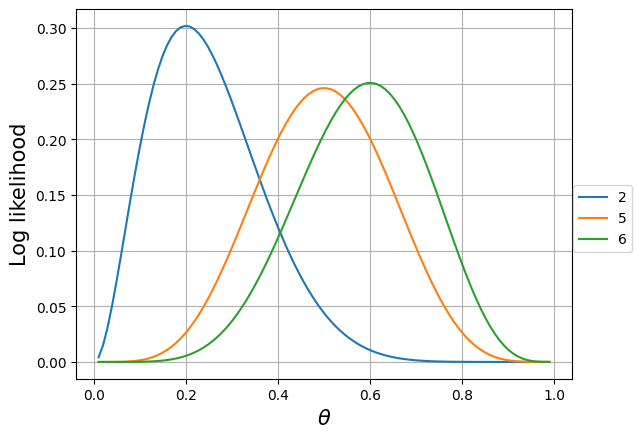

In [10]:
lf_plot(10)

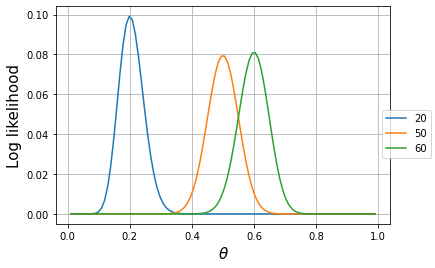

In [ ]:
lf_plot(100)

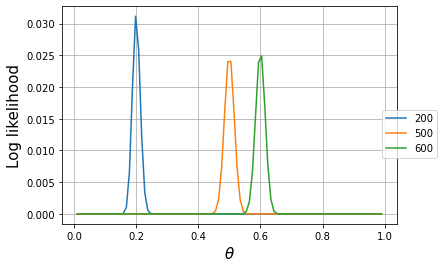

In [ ]:
lf_plot(1000)

The posterior distribution in Bayesian statistics combines the information in the likelihood and the prior.  Specifically, the posterior distribution is proportional to the likelihood times the prior.  The prior reflects the knowledge about the parameter that do not come from the data.  

When analyzing data using Bayesian methods, we can choose a prior.  A natural choice for the prior $p(\theta)$ for a binomial model is a uniform distribution on the unit interval $[0, 1]$.  In this case, the prior $p(\theta)$ is identically equal to 1, so the plots above showing likelihood functions also show the posterior distribution $p(\theta|D)$.

ベイズ統計における事後分布は、尤度と事前分布の情報を組み合わせたものです。具体的には、事後分布は尤度と事前分布の積に比例します。事前分布は、データ由来ではないパラメータに関する知識を表します。

ベイズ手法でデータを分析する際には、事前分布を選択できます。二項モデルに対する事前分布 $p(\theta)$ としては、区間 $[0, 1]$ 上の一様分布が自然です。この場合、事前分布 $p(\theta)$ は常に 1 なので、上で示した尤度関数の図はそのまま事後分布 $p(\theta|D)$ も表していることになります。

### Beta priors

Now suppose we have a strong reason to believe that our coin is fair, and wish to analyze the data in light of this prior knowledge.  To accomplish this, we can use a non-uniform prior that is concentrated around 1/2.  A convenient way to specify a prior for a parameter such as $\theta$, which is a probability that falls between 0 and 1, is to use a [beta distribution](https://en.wikipedia.org/wiki/Beta_distribution).  The beta distribution depends on two *shape parameters* $\alpha$ and $\beta$.  Below we graph the density function (pdf) of a beta distribution when $\alpha=\beta=2$.  This particular beta distribution places the greatest prior mass at 1/2, with symmetrically diminishing prior probability for values of $\theta$ close to either 0 or 1.  You can modify the values of $\alpha$ and $\beta$ to see the shape of the prior for other settings of the shape parameters.

### Beta事前分布

次に、コインが公平であると強く信じる理由があり、その事前知識を反映してデータを分析したいとします。この目的には、1/2 付近に集中する非一様な事前分布を使います。$\theta$ のように 0 から 1 の範囲をとる確率パラメータの事前分布を指定するには、[ベータ分布](https://en.wikipedia.org/wiki/Beta_distribution) が便利です。ベータ分布は2つの*形状パラメータ* $\alpha$ と $\beta$ によって決まります。以下では、$\alpha=\beta=2$ のときのベータ分布の密度関数（pdf）を描画します。この分布は 1/2 で最も大きな事前確率を持ち、$\theta$ が 0 や 1 に近づくほど対称的に事前確率が小さくなります。$\alpha$ と $\beta$ の値を変更すると、形状パラメータの違いによる事前分布の形を確認できます。

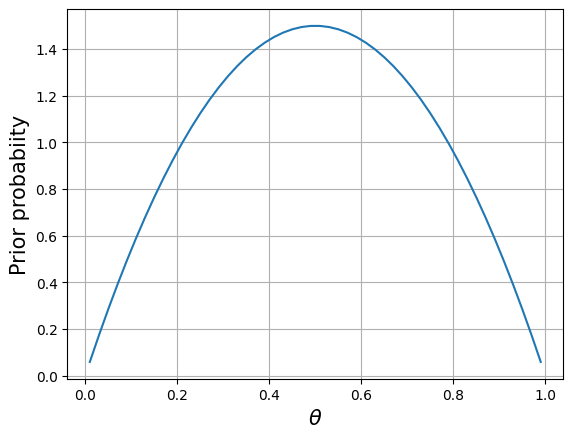

In [17]:
alpha = 2
beta = 2
theta = np.linspace(0.01, 0.99)
plt.grid(True)
plt.plot(theta, st.beta.pdf(theta, alpha, beta))
plt.xlabel(r"$\theta$", size=15)
plt.ylabel("Prior probabiity", size=15);

The function below calculates the posterior distribution (up to a proportionality constant) for a dataset consisting of $x$ heads out of $n$ trials, using a Beta prior distribution with the given values of the shape parameters $\alpha$ and $\beta$. 

次の関数は、$n$ 回の試行で $x$ 回表が出たデータに対し、形状パラメータ $\alpha$、$\beta$ を持つ Beta 事前分布を用いて、事後分布（比例定数まで）を計算します。

In [18]:
def post(x, n, alpha, beta, theta):
    return st.binom.pmf(x, n, theta) * st.beta.pdf(theta, alpha, beta)

The example below illustrates the difference between Bayesian and frequentist inference in this setting.  If we observe $x$ heads out of $n$ tosses of the coin, we can use a Beta prior distribution with the given shape parameters to estimate $\theta$ (the true probability of the coin landing heads-up).

The blue and orange curves depict the posterior distribution for two different priors.  In Bayesian analysis, the posterior distribution reflects all relevant information in the data about the parameter.  Using a relatively flat prior ($\alpha=\beta=1$, orange curve) the posterior distribution has a peak very close to the MLE.  The dispersion of the posterior distribution reflects the precision of this estimate.  If we instead use a more concentrated prior with $\alpha=\beta=10$, the mode of the posterior is shrunk toward the mean of the prior distribution, which is $1/2$.  The posterior is also somewhat more concentrated as we are using a more concentrated prior.

The black horizontal line in the graph is the MLE, which always falls at $x/n$.

以下の例は、この設定におけるベイズ推論と頻度主義推論の違いを示しています。コイン投げで $n$ 回中 $x$ 回の表を観測したとき、指定した形状パラメータの Beta 事前分布を使って $\theta$（コインが表になる真の確率）を推定できます。

青とオレンジの曲線は、2つの異なる事前分布に対する事後分布です。ベイズ分析では、事後分布がデータとパラメータに関する関連情報を統合して表します。比較的平坦な事前分布（$\alpha=\beta=1$、オレンジ）を使うと、事後分布のピークは MLE に非常に近くなります。事後分布の広がりはこの推定の精度を反映します。一方、より集中した事前分布（$\alpha=\beta=10$）を使うと、事後分布の最頻値は事前分布の平均である $1/2$ の方向へ縮小（shrink）します。また、事前分布がより集中しているため、事後分布もやや集中します。

図中の黒い縦線は MLE を示しており、その位置は常に $x/n$ です。

Text(0, 0.5, 'Posterior probability\n(not normalized)')

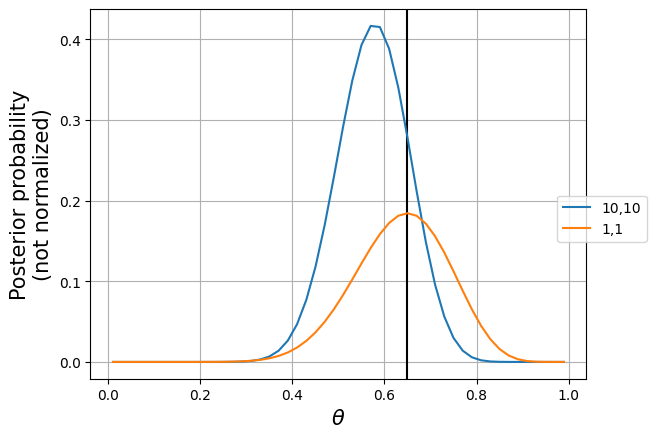

In [19]:
x = 13
n = 20
plt.grid(True)
plt.axvline(x/n, color="black")
alpha, beta = 10, 10
po = post(x, n, 10, 10, theta)
plt.plot(theta, po, label="10,10")
alpha, beta = 1, 1
po = post(x, n, 1, 1, theta)
plt.plot(theta, po, label="1,1")
ha, lb = plt.gca().get_legend_handles_labels()
plt.figlegend(ha, lb, loc="center right")
plt.xlabel(r"$\theta$", size=15)
plt.ylabel("Posterior probability\n(not normalized)", size=15)

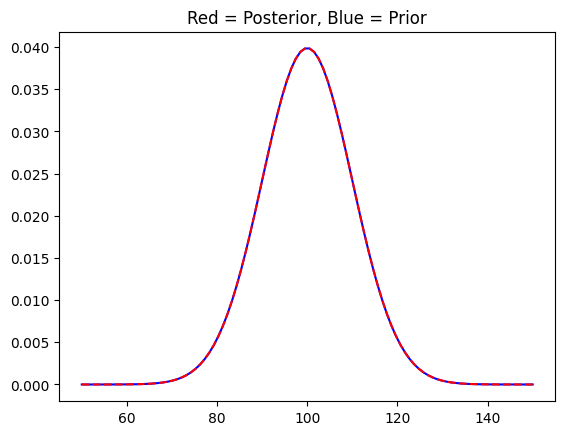

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st
import math

# Set a random seed for repeated computation
np.random.seed(123)

# Global constants - these are what we need to change
# This is my inital belief about the mean of the average IQ score on campus
prior_sigma = 10 # my uncertainty about the mean
prior_mean = 100 # my initial belief about the mean
sigma_observations = 3 # uncertainty in my observations

# New observations - We are going to be updating this list to see how observing
# different data changes our beliefs about the average IQ score
new_data = []

# Compute some statistics on the new data
n = len(new_data) 

# Some hairy math to avoid doing integrals (Wikipedia has the math!)
if n != 0:
  posterior_mean = (( 1 / prior_sigma ** 2) + n / sigma_observations ** 2)**(-1) * ((prior_mean / prior_sigma ** 2) + sum(new_data) / sigma_observations ** 2)
  posterior_sd = (1 / prior_sigma ** 2 + n / sigma_observations ** 2)**(-1)
else:
  posterior_mean = prior_mean
  posterior_sd = prior_sigma
  
# Plot the distribution of the prior and the posterior
x = np.linspace(50, 150, 100)
plt.plot(x, st.norm.pdf(x, loc=prior_mean, scale=prior_sigma), color="blue")
plt.plot(x, st.norm.pdf(x, loc=posterior_mean, scale=posterior_sd), color="red", linestyle="--")
plt.title("Red = Posterior, Blue = Prior")

# To view the graph, comment-out print(posterior_mean)
# To view the numerical output, comment-out plt.show()

plt.show()
#print(posterior_mean)

### 質問 1

この問題では、「統計とモデリングへのベイズ・アプローチ」の講義の背後にある数学の一部を再現するために、上記のコードを使用します。数学はすでに計算されているので、コードを操作するだけですが、分布の平均の更新の背後にある数学に興味があれば、
https://en.wikipedia.org/wiki/Conjugate_prior。
この問題の計算は、連続分布のセクションにあり、モデルパラメーターはmuで、既知の分散sigma^2があります。

始める前に、いくつかのVALUEを得る必要があります。 

まず、我々が使っている事前分布の平均は何でしょうか？

#### 解答（質問1）

**答え：100**

計算過程：
- 事前平均はコード中の `prior_mean` です。
- 設定値は `prior_mean = 100`。

したがって、事前分布の平均は **100** です。

### 質問 2
事前分布の標準偏差は？

#### 解答（質問2）

**答え：10**

計算過程：
- 事前分布の標準偏差はコード中の `prior_sigma`。
- 設定値は `prior_sigma = 10`。

したがって、事前分布の標準偏差は **10** です。

###  質問 3
IQ110の人を観察したとしましょう。ベイズ更新後の事後分布はどちらにシフトすべきでしょうか？

1. 左
2. 右
3. 変わらない

#### 解答（質問3）

**答え：2. 右**

計算過程：
- 事前平均は 100。
- 観測値は 110（事前平均より大きい）。
- 正規-正規共役では、事後平均は「事前平均」と「観測平均」の重み付き平均になるため、100 から 110 側へ移動します。

したがって、事後分布は **右** にシフトします。

### 質問 4
さて、さらに2人の人を観察して、彼らもIQが110であることがわかったとしましょう。つまり、IQ110の人が3人いることになります。私の推定の分散は、私の事前予測からどのように変わるでしょうか？これをコードで行うには、次のように設定します：

1. 分散の減少
2. 分散の増加
3. 分散は同じまま

#### 解答（質問4）

**答え：1. 分散の減少**

計算過程：
- 事後分散（このノートの式）は
  $v_n = \left(\frac{1}{\sigma_0^2} + \frac{n}{\sigma^2}\right)^{-1}$
- `n` が増えると、括弧内の値は大きくなり、逆数は小さくなる。
- つまりデータが増えるほど不確実性は下がる。

したがって、3人分の観測後は分散は **減少** します。

### 質問 5

IQ110の人を3人連続で観察した後の事後平均は？

#### 解答（質問5）

**答え：事後平均は約 109.724**

計算過程：
- 前提：事前平均 $\mu_0=100$、事前標準偏差 $\sigma_0=10$、観測ノイズ標準偏差 $\sigma=3$
- データ：110, 110, 110 なので $n=3$, $\sum x_i=330$
- 事後平均の式：
  $\mu_n = \left(\frac{1}{\sigma_0^2}+\frac{n}{\sigma^2}\right)^{-1}\left(\frac{\mu_0}{\sigma_0^2}+\frac{\sum x_i}{\sigma^2}\right)$
- 数値代入：
  $\left(\frac{1}{100}+\frac{3}{9}\right)^{-1}=\left(0.01+0.3333\right)^{-1}=2.912621$
  $\frac{100}{100}+\frac{330}{9}=1+36.6667=37.6667$
  $\mu_n=2.912621\times 37.6667\approx 109.724$

したがって、事後平均は **約109.724** です。

### 質問 6
最初の3人のIQは110、後の2人のIQは125です。
以下の選択肢から正しいものをすべて選んで下さい


- 事後平均は110, 110, 110, 125, 125の平均。
- 事後平均は110
- 事後平均は100
- 事後平均は125
- 事後平均は 115.717  
- 事後標準偏差は事前標準偏差と同じです。 
- 事後標準偏差が事前標準偏差より大きい 
- 事後標準偏差が事前標準偏差より小さい
- 事後標準偏差は10
- 事後標準偏差は1.768 
- 事後標準偏差は3



#### 解答（質問6）

**正しい選択肢**
- 事後平均は 115.717
- 事後標準偏差が事前標準偏差より小さい
- 事後標準偏差は1.768

計算過程：
- データは 110, 110, 110, 125, 125 なので
  $n=5$, $\sum x_i=580$
- 事後平均：
  $\mu_n = \left(\frac{1}{100}+\frac{5}{9}\right)^{-1}\left(\frac{100}{100}+\frac{580}{9}\right)$
  $= (0.565556)^{-1}(65.4444)$
  $= 1.767956 \times 65.4444 \approx 115.717$
- このノートの実装での `posterior_sd` は
  $\left(\frac{1}{100}+\frac{5}{9}\right)^{-1}=1.767956\approx1.768$
- 事前値 10 と比べると 1.768 は小さい。

注記：理論的に標準偏差を厳密に書くなら $\sqrt{1.768}\approx1.33$ ですが、この演習はコード中の `posterior_sd`（= 1.768）を基準に選択肢判定する構成です。

よって、該当する選択肢は上の3つです。